In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import svm
from sklearn import tree

In [2]:
df_row=pd.read_csv(r"C:\Users\EXIRIM_Compurer's\Downloads\insurance.csv")
df_row.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df_row.shape

(1338, 7)

In [4]:
df_row.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df_row.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


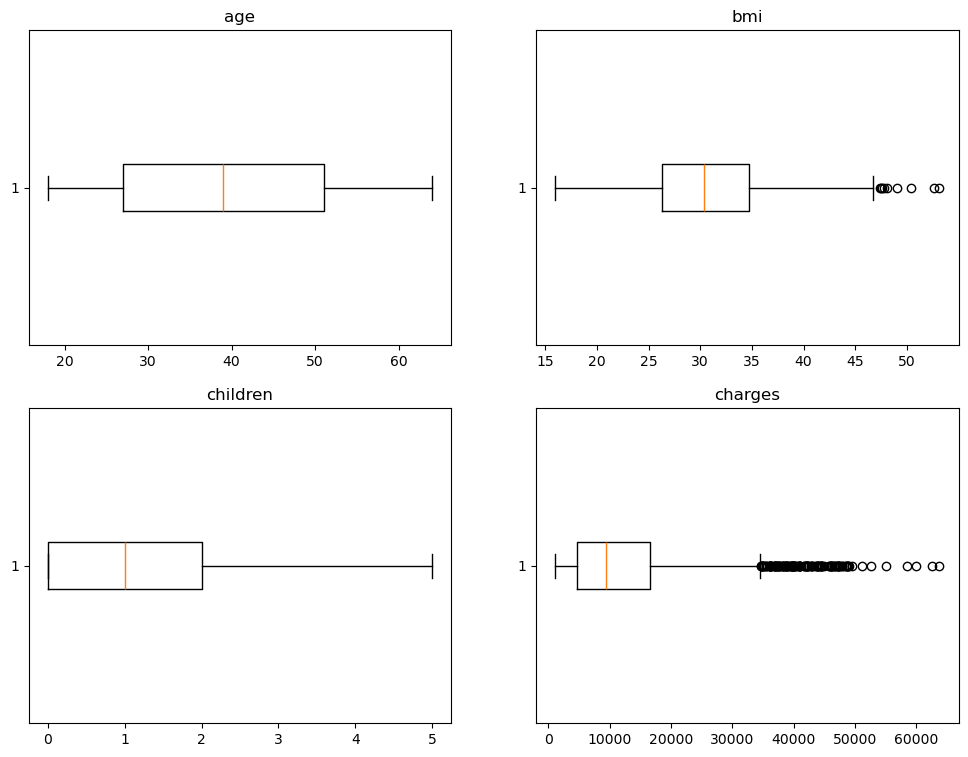

In [6]:
num_cols=[col for col in df_row.columns if df_row[col].dtype!= 'object' ]
plt.figure(figsize=(12,9))
for i,col in enumerate(num_cols,1):
    plt.subplot(2,2,i)
    plt.boxplot(df_row[col],vert=False)
    plt.title(col)


In [7]:
q1,q3=np.percentile(df_row['bmi'],[25,75])
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr



df=df_row[(df_row['bmi']>=lower) & (df_row['bmi']<= upper)]
df.shape

(1329, 7)

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
lbl=LabelEncoder()
df['sex']=lbl.fit_transform(df['sex'])
lbl2=LabelEncoder()
df['smoker']=lbl2.fit_transform(df['smoker'])



C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_6208\1147246217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex']=lbl.fit_transform(df['sex'])
C:\Users\EXIRIM_Compurer's\AppData\Local\Temp\ipykernel_6208\1147246217.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoker']=lbl2.fit_transform(df['smoker'])


In [10]:
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(df, columns=['region'])



In [11]:
df.shape

(1329, 10)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1329 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1329 non-null   int64  
 1   sex               1329 non-null   int64  
 2   bmi               1329 non-null   float64
 3   children          1329 non-null   int64  
 4   smoker            1329 non-null   int64  
 5   charges           1329 non-null   float64
 6   region_northeast  1329 non-null   bool   
 7   region_northwest  1329 non-null   bool   
 8   region_southeast  1329 non-null   bool   
 9   region_southwest  1329 non-null   bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 77.9 KB


In [13]:
X=df.drop('charges',axis=1)
y=df['charges']


In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
std=StandardScaler()

In [15]:
cols=df.drop('charges',axis=1).columns
df[cols] = std.fit_transform(df[cols])


In [16]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,-1.008311,-0.445670,-0.907940,1.975869,16884.92400,-0.566634,-0.568951,-0.606040,1.761207
1,-1.509976,0.991757,0.546267,-0.079764,-0.506106,1725.55230,-0.566634,-0.568951,1.650057,-0.567792
2,-0.797855,0.991757,0.416149,1.576587,-0.506106,4449.46200,-0.566634,-0.568951,1.650057,-0.567792
3,-0.441794,0.991757,-1.323542,-0.907940,-0.506106,21984.47061,-0.566634,1.757621,-0.606040,-0.567792
4,-0.513006,0.991757,-0.280065,-0.907940,-0.506106,3866.85520,-0.566634,1.757621,-0.606040,-0.567792


In [17]:
df.corr()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,-0.019143,0.114686,0.043041,-0.024505,0.302022,0.001766,-0.000283,-0.011581,0.010474
sex,-0.019143,1.000000,0.039958,0.019281,0.079854,0.063394,0.000573,-0.009961,0.010263,-0.001195
bmi,0.114686,0.039958,1.000000,0.017355,-0.002871,0.193196,-0.136193,-0.128598,0.255863,0.000651
children,0.043041,0.019281,0.017355,1.000000,0.007577,0.069739,-0.024857,0.024209,-0.018816,0.020021
smoker,-0.024505,0.079854,-0.002871,0.007577,1.000000,0.785912,0.004947,-0.035940,0.068270,-0.039440
charges,0.302022,0.063394,0.193196,0.069739,0.785912,1.000000,0.009750,-0.037704,0.071597,-0.045906
region_northeast,0.001766,0.000573,-0.136193,-0.024857,0.004947,0.009750,1.000000,-0.322387,-0.343402,-0.321730
region_northwest,-0.000283,-0.009961,-0.128598,0.024209,-0.035940,-0.037704,-0.322387,1.000000,-0.344807,-0.323046
region_southeast,-0.011581,0.010263,0.255863,-0.018816,0.068270,0.071597,-0.343402,-0.344807,1.000000,-0.344105
region_southwest,0.010474,-0.001195,0.000651,0.020021,-0.039440,-0.045906,-0.321730,-0.323046,-0.344105,1.000000


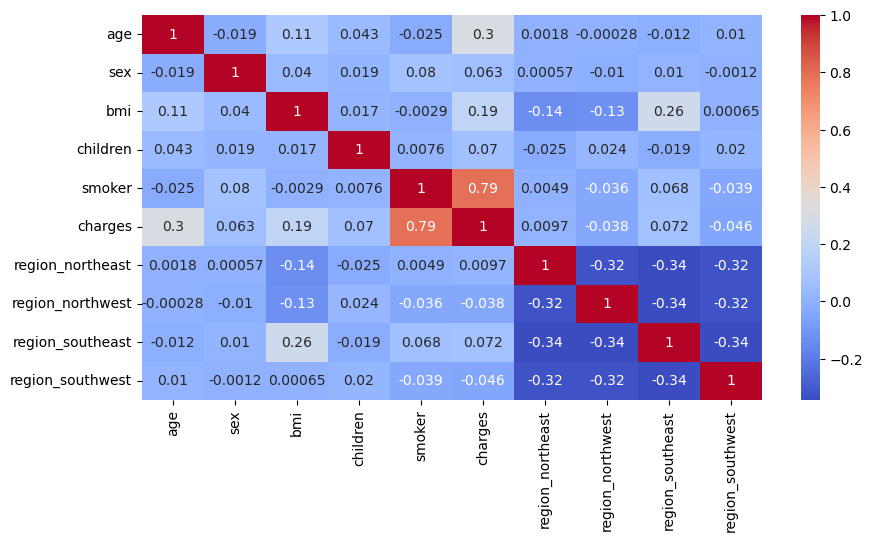

In [18]:
import seaborn as sns 
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [19]:
df = df.drop(['region_northwest'], axis=1)
# all region columns are removed

In [20]:
df.corr()['charges'].sort_values(ascending=False)

charges             1.000000
smoker              0.785912
age                 0.302022
bmi                 0.193196
region_southeast    0.071597
children            0.069739
sex                 0.063394
region_northeast    0.009750
region_southwest   -0.045906
Name: charges, dtype: float64

In [21]:
df.shape

(1329, 9)

In [22]:
lr=LinearRegression()
lr.fit(X_train,y_train)



LinearRegression()

In [23]:
y_pred=lr.predict(X_test)

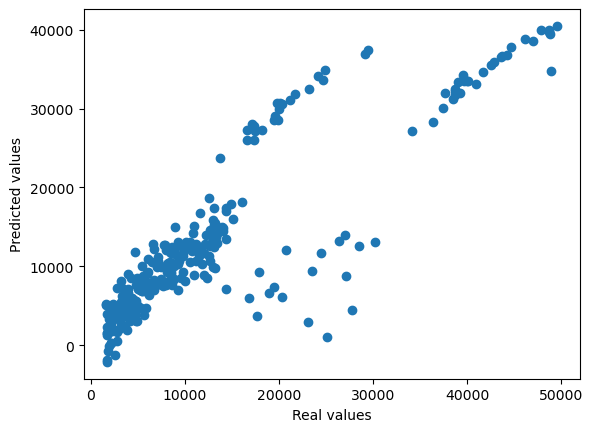

In [24]:




plt.scatter(y_test, y_pred)
plt.xlabel("Real values")
plt.ylabel("Predicted values")
plt.show()


In [25]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [26]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)**0.5)
print("R2:",r2_score(y_test,y_pred))

MAE: 4084.927484556656
RMSE: 5873.562032264931
R2: 0.7671119511350496


In [27]:
y_tr_pred=lr.predict(X_train)
y_tst_pred=lr.predict(X_test)

print("Train R2:",r2_score(y_train,y_tr_pred))
print("Test R2:",r2_score(y_test,y_tst_pred))

Train R2: 0.7454367820598464
Test R2: 0.7671119511350496


In [28]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

In [29]:
svr=SVR(kernel='linear',C=1000)
svr.fit(X_train,y_train)

SVR(C=1000, kernel='linear')

In [30]:
y_pred_svr=svr.predict(X_test)

In [31]:
print("MAE:",mean_absolute_error(y_test,y_pred_svr))
print("RMSE:",mean_squared_error(y_test,y_pred_svr)**0.5)
print("R2:",r2_score(y_test,y_pred_svr))

MAE: 3632.10155411453
RMSE: 6886.071233540965
R2: 0.6798989455745347


In [32]:
y_tr_pred_svr=svr.predict(X_train)
y_tst_pred_svr=svr.predict(X_test)

print("Train R2:",r2_score(y_train,y_tr_pred_svr))
print("Test R2:",r2_score(y_test,y_tst_pred_svr))

Train R2: 0.6646038565862117
Test R2: 0.6798989455745347


In [33]:
df['smoker x age']=df['smoker']*df['age']
df['age x bmi']=df['age']*df['bmi']
df['bmi x smoker']=df['bmi']*df['smoker']
df.shape

(1329, 12)

In [34]:
df.corr()

,age,sex,bmi,children,smoker,charges,region_northeast,region_southeast,region_southwest,smoker x age,age x bmi,bmi x smoker
age,1.000000,-0.019143,0.114686,0.043041,-0.024505,0.302022,0.001766,-0.011581,0.010474,-0.008642,0.032581,-0.022492
sex,-0.019143,1.000000,0.039958,0.019281,0.079854,0.063394,0.000573,0.010263,-0.001195,0.006988,0.021515,0.064892
bmi,0.114686,0.039958,1.000000,0.017355,-0.002871,0.193196,-0.136193,0.255863,0.000651,-0.022955,-0.035495,0.018708
children,0.043041,0.019281,0.017355,1.000000,0.007577,0.069739,-0.024857,-0.018816,0.020021,0.019143,0.015756,-0.013612
smoker,-0.024505,0.079854,-0.002871,0.007577,1.000000,0.785912,0.004947,0.068270,-0.039440,-0.036257,-0.022897,-0.004162
charges,0.302022,0.063394,0.193196,0.069739,0.785912,1.000000,0.009750,0.071597,-0.045906,-0.014793,-0.013518,0.288616
region_northeast,0.001766,0.000573,-0.136193,-0.024857,0.004947,0.009750,1.000000,-0.343402,-0.321730,-0.007105,0.022375,-0.026301
region_southeast,-0.011581,0.010263,0.255863,-0.018816,0.068270,0.071597,-0.343402,1.000000,-0.344105,0.036210,-0.057166,0.010221
region_southwest,0.010474,-0.001195,0.000651,0.020021,-0.039440,-0.045906,-0.321730,-0.344105,1.000000,-0.046714,0.051275,0.008584
smoker x age,-0.008642,0.006988,-0.022955,0.019143,-0.036257,-0.014793,-0.007105,0.036210,-0.046714,1.000000,0.012788,0.080527


In [35]:
lr.fit(X_train,y_train)
y_pred_2=lr.predict(X_test)

In [36]:
print("MAE:",mean_absolute_error(y_test,y_pred_2))
print("RMSE:",mean_squared_error(y_test,y_pred_2)**0.5)
print("R2:",r2_score(y_test,y_pred_2))

MAE: 4084.927484556656
RMSE: 5873.562032264931
R2: 0.7671119511350496


In [37]:
from sklearn import tree
from scipy.stats import randint

In [38]:
tre=tree.DecisionTreeRegressor()
params={
    'max_depth':[3,None],
    'min_samples_leaf': randint(1,20),
    "min_samples_split": randint(2, 20),
    "max_features": [None, "sqrt", "log2"],
    "criterion": ["squared_error", "friedman_mse", "absolute_error"]

}

random_search=RandomizedSearchCV(tre,param_distributions=params,n_iter=20,cv=5,scoring='r2',n_jobs=-1,random_state=42)
random_search.fit(X_train,y_train)
y_pred_tre=random_search.predict(X_test)

In [39]:
print("MAE:",mean_absolute_error(y_test,y_pred_tre))
print("RMSE:",mean_squared_error(y_test,y_pred_tre)**0.5)
print("R2:",r2_score(y_test,y_pred_tre))

MAE: 1753.9517541353384
RMSE: 4469.732658062571
R2: 0.8651325398507633


In [40]:
y_tr_pred_tre=random_search.predict(X_train)
y_tst_pred_tre=random_search.predict(X_test)

print("Train R2:",r2_score(y_train,y_tr_pred_tre))
print("Test R2:",r2_score(y_test,y_tst_pred_tre))

Train R2: 0.8550433530256503
Test R2: 0.8651325398507633


In [41]:
from sklearn.metrics import accuracy_score